In [323]:
import pandas as pd
import numpy as np
import json
from pandas import json_normalize
import matplotlib.pyplot as plt
import seaborn as sns
import ast
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity
# from sklearn.metrics import pairwise_distances
# from sklearn.metrics.pairwise import euclidean_distances
# from scipy.spatial import distance
from sentence_transformers import SentenceTransformer

In [2]:
def load_data(path = "tags-20210226.csv"):
    return pd.read_csv(path)


In [3]:
# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

## Tags EDA

In [4]:

df_tags = load_data()

In [5]:
df_tags.head(5)

,id,type,name,canonical,cached_count,merger_id
0,1,Media,TV Shows,True,910,NaN
1,2,Media,Movies,True,1164,NaN
2,3,Media,Books & Literature,True,134,NaN
3,4,Media,Cartoons & Comics & Graphic Novels,True,166,NaN
4,5,Media,Anime & Manga,True,501,NaN


In [6]:
print(f"Shape: {df_tags.shape}")
print(f"\nColumn types:\n{df_tags.dtypes}")

Shape: (14467138, 6)

Column types:
id                int64
type             object
name             object
canonical          bool
cached_count      int64
merger_id       float64
dtype: object


In [7]:
df_tags.describe(include='all').round(2)

,id,type,name,canonical,cached_count,merger_id
count,14467138.00,14467138,14467135,14467138,14467138.00,3466917.00
unique,NaN,9,1621973,2,NaN,NaN
top,NaN,Freeform,Redacted,False,NaN,NaN
freq,NaN,9244331,12845163,13291100,NaN,NaN
mean,27166031.48,NaN,NaN,NaN,10.15,14412910.06
std,16681853.91,NaN,NaN,NaN,2093.44,16735997.56
min,1.00,NaN,NaN,NaN,0.00,25.00
25%,12466060.00,NaN,NaN,NaN,1.00,227826.00
50%,27524572.00,NaN,NaN,NaN,1.00,6541412.00
75%,41748064.75,NaN,NaN,NaN,1.00,26810423.00


### Cleaning tag data

In [8]:
df_tags.isnull().sum()

id                     0
type                   0
name                   3
canonical              0
cached_count           0
merger_id       11000221
dtype: int64

In [9]:
print(f"Percentage of missing values in merger_id  column {df_tags["merger_id"].isna().mean() * 100 :.2f} %")

Percentage of missing values in merger_id  column 76.04 %


I don't need merger id and it is mostly missing values (76%) I will drop the three missing tags and merger id column 

In [250]:
df_tags_clean= df_tags.copy()

In [251]:
df_tags_clean = df_tags_clean.drop(columns=['merger_id'])

In [252]:
df_tags_clean = df_tags_clean.dropna(subset=['name'])

### Plot  tags

in ao3 there are different types of tags 

In [253]:
df_tags_clean["type"].unique()

array(['Media', 'Rating', 'ArchiveWarning', 'Category', 'Character',
       'Fandom', 'Relationship', 'Freeform', 'UnsortedTag'], dtype=object)

In [254]:
media = df_tags_clean[df_tags_clean["type"] == "Media"]

In [257]:
media.head()

,id,type,name,canonical,cached_count
0,1,Media,TV Shows,True,910
1,2,Media,Movies,True,1164
2,3,Media,Books & Literature,True,134
3,4,Media,Cartoons & Comics & Graphic Novels,True,166
4,5,Media,Anime & Manga,True,501


In [294]:
def plot_type(type, title="type", figsize=(8,8), offset = 0):
    plt.figure(figsize=figsize)
    plt.plot(type['name'], type['cached_count'], marker='o', linestyle='-', color='black')
    peak = type["cached_count"].idxmax()
    peak_x = type.loc[peak, 'name']
    peak_y = type.loc[peak, 'cached_count']
        
    plt.scatter(peak_x, peak_y, color='red', s=100, zorder=5)
    plt.annotate(
    f'{peak_x}: {peak_y}',
    xy=(peak_x, peak_y),
    xytext=(peak_x, peak_y + offset),
    
)

    
    plt.xlabel('Name of Tag')
    plt.ylabel('Count')
    plt.title(f"Count of Fan Works Based on {title}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()


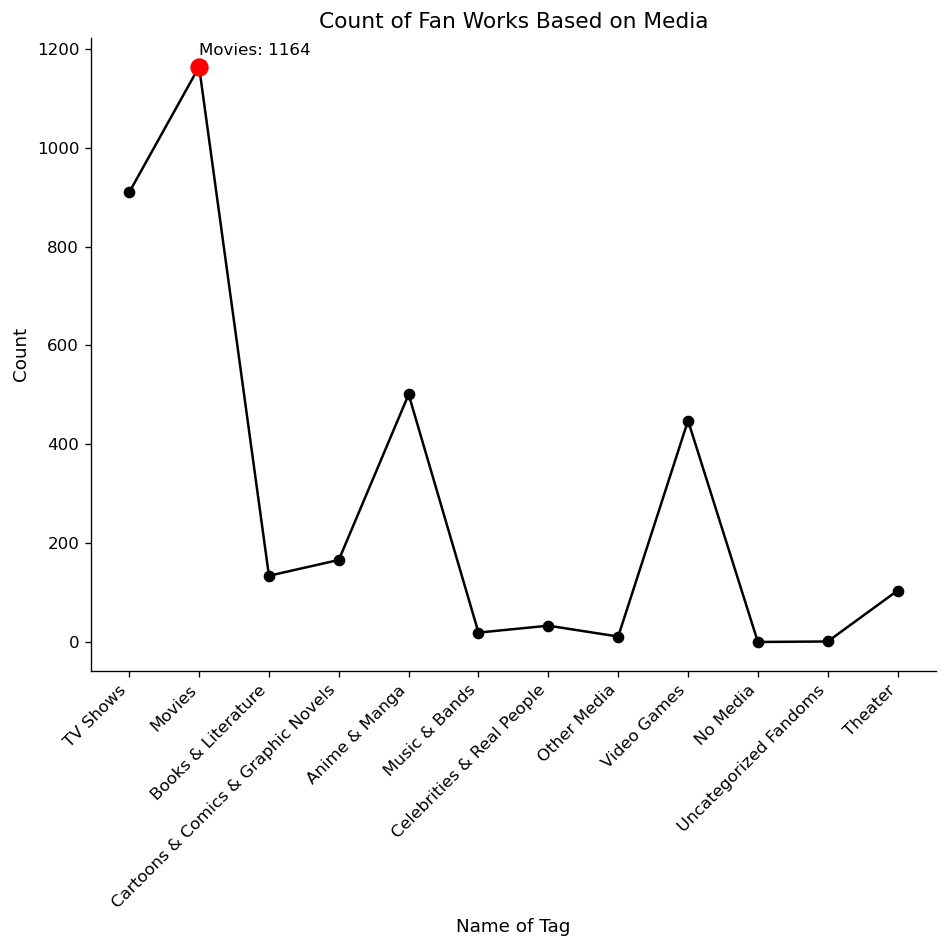

In [295]:
plot_type(media, "Media", offset=23)


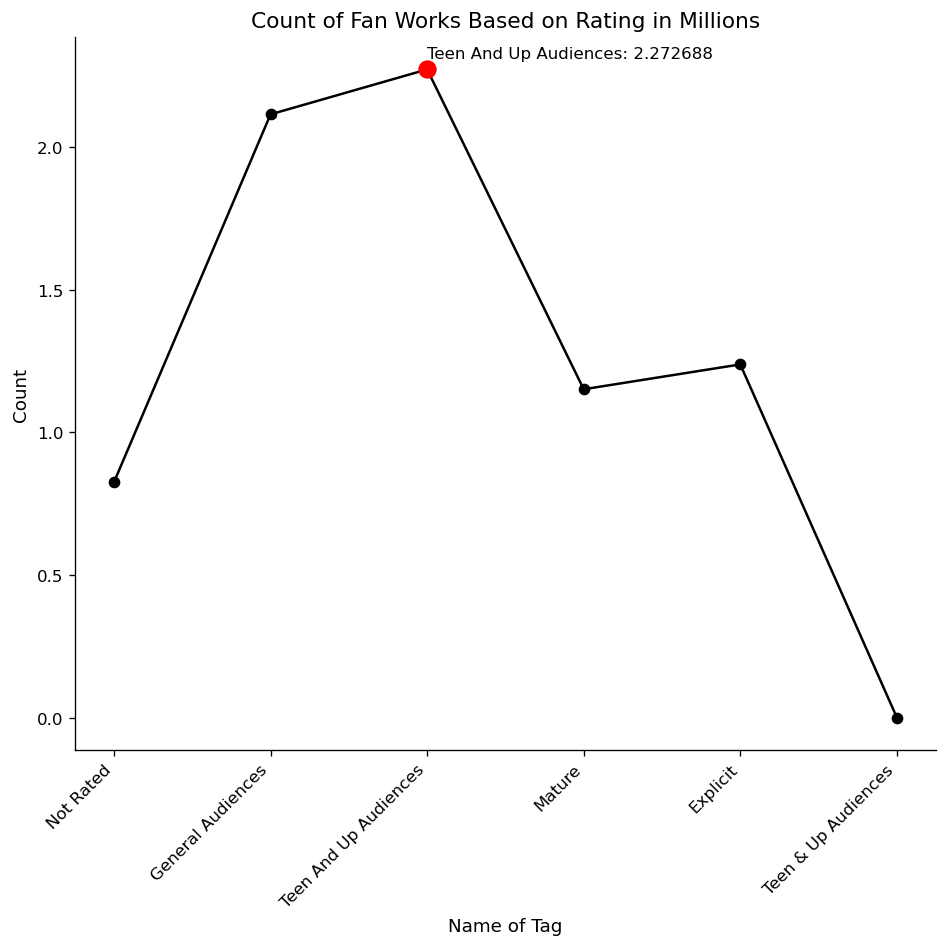

In [296]:
rate = df_tags_clean[df_tags_clean["type"] == "Rating"].copy()
rate["cached_count"] = rate["cached_count"] / 1000000
plot_type(rate, "Rating in Millions", offset= 0.04)

In [297]:
fandom = df_tags_clean[df_tags_clean["type"] == "Fandom"].copy()
# rate["cached_count"] = rate["cached_count"] / 1000000

fandom = fandom.sort_values(by='cached_count', ascending=False)
fandom_20 = fandom.head(10)

In [298]:
fandom.head(10)

,id,type,name,canonical,cached_count
94292,136512,Fandom,Harry Potter - J. K. Rowling,True,361919
25,27,Fandom,Supernatural,True,310300
230408,414093,Fandom,Marvel Cinematic Universe,True,240536
1553725,3828398,Fandom,僕のヒーローアカデミア | Boku no Hero Academia | My Hero ...,True,204096
680695,1002903,Fandom,방탄소년단 | Bangtan Boys | BTS,True,203097
168289,258526,Fandom,Teen Wolf (TV),True,172802
679946,1001939,Fandom,The Avengers (Marvel Movies),True,157813
92059,133185,Fandom,Sherlock (TV),True,151925
5974,7266,Fandom,Marvel,True,147757
494603,758208,Fandom,Haikyuu!!,True,130918


C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\970521297.py:21: UserWarning: Glyph 20693 (\N{CJK UNIFIED IDEOGRAPH-50D5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\970521297.py:21: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\970521297.py:21: UserWarning: Glyph 12498 (\N{KATAKANA LETTER HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\970521297.py:21: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\970521297.py:21: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\970521297.py:21: UserWarning: Glyph 12450 (\N{KATA

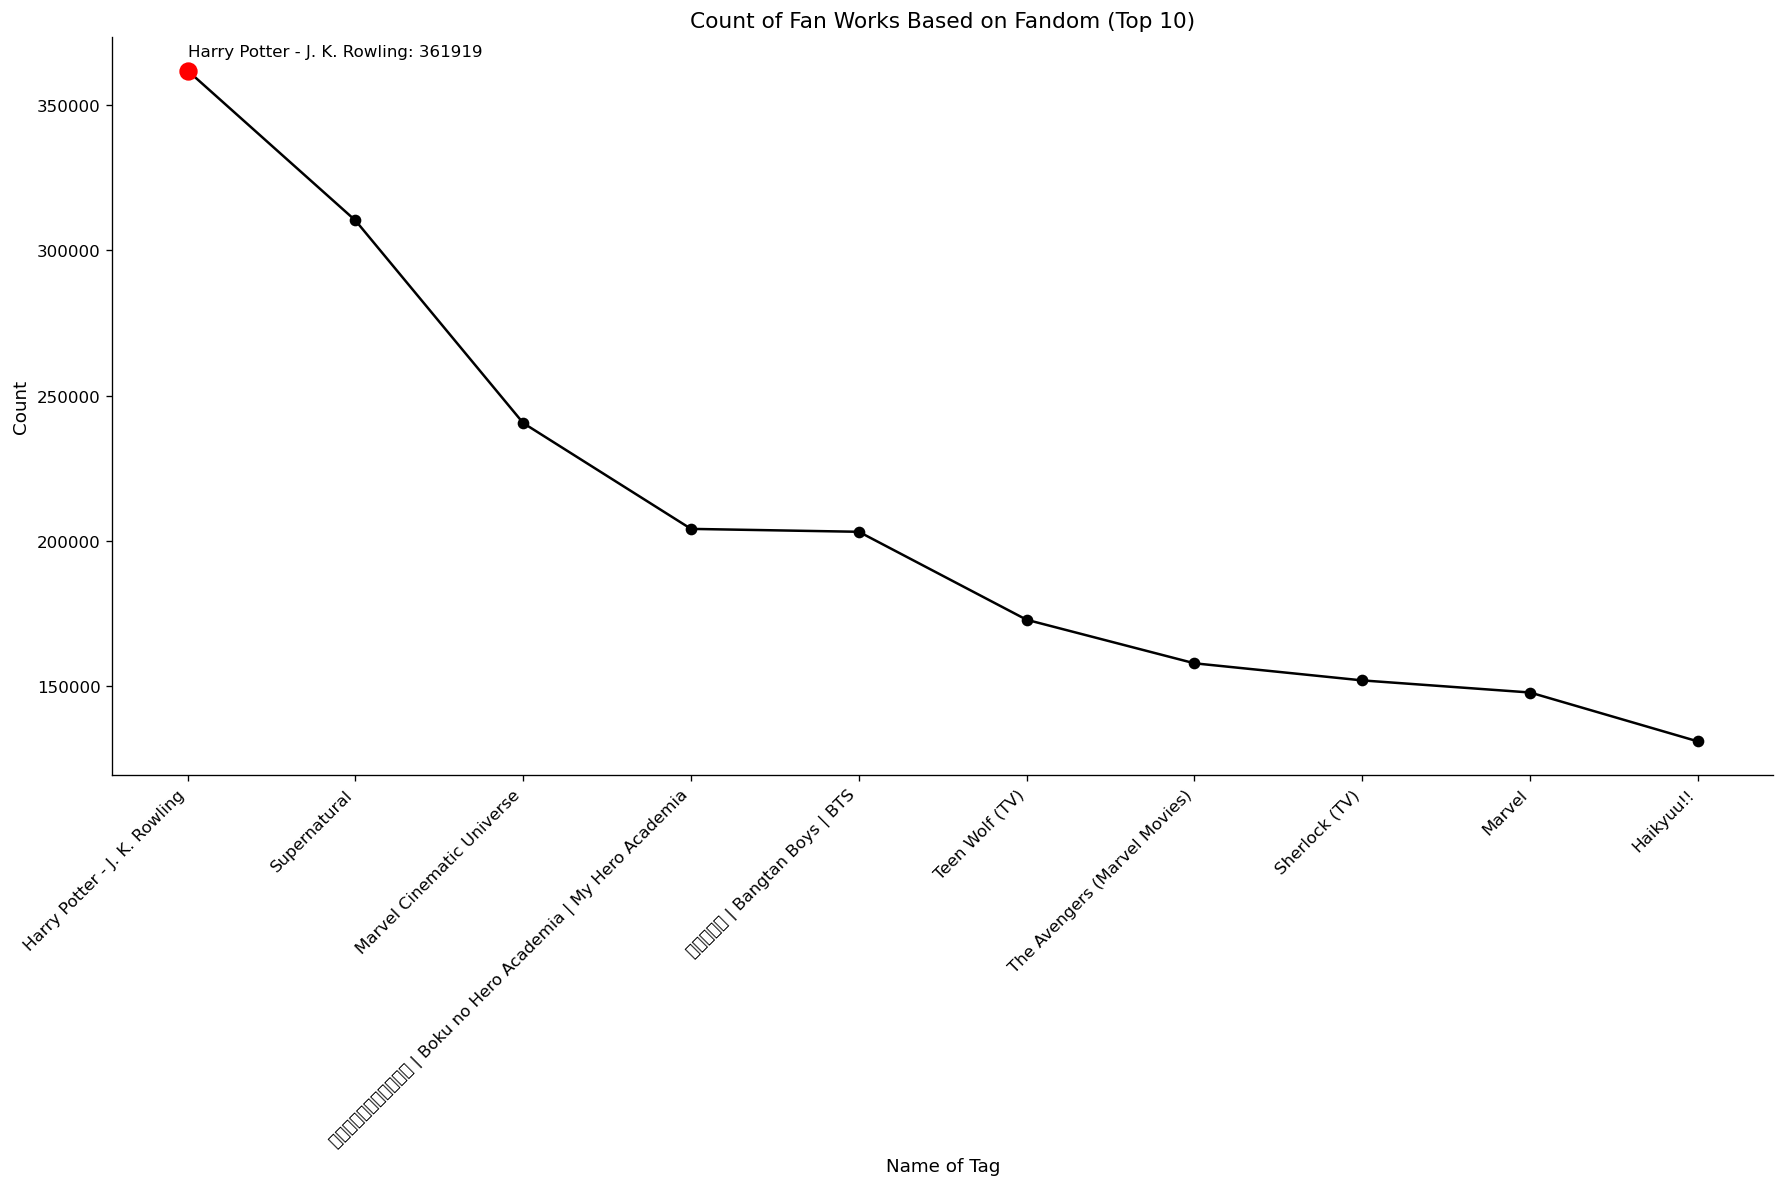

In [306]:
plot_type(fandom_20, "Fandom (Top 10)", figsize=(15,10), offset=5000)

based on the information so far most works are rates teen and up or general audience and most works are in movies or tv show category

## Works Metadata with no text

In [31]:
df_works = load_data(path = "random works - Oct 2025.csv")

In [32]:
df_works.head(10)

,Unnamed: 0,URL,Title,Authors,Rating Tags,Warning Tags,Category Tags,Fandom Tags,Relationship Tags,Character Tags,...,Chapters,Intended_chapters,Words,Comments,Kudos,Bookmarks,Hits,Summary Paragraphs,Summary Words,Summary Characters
0,0,https://archiveofourown.org/works/33980032,Warm Hugs from Close Friends,"['AbsentReverie', 'NightTanzy']",[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' F/M'],"['Persona Series', 'Persona 3', 'Persona 4']","['Arisato Minako/Narukami Yu', 'Female Persona...","['Arisato Minako', 'Arisato Minato', 'Narukami...",...,1,1,2648,3,29,1,671,4,179,1033
1,1,https://archiveofourown.org/works/33979747,Tornado Warning,['coughsyrup'],[' Explicit'],"[' Rape/Non-Con', 'Underage Sex']",[' M/M'],['Persona 4'],['Adachi Tohru/Tatsumi Kanji'],"['Adachi Tohru', 'Tatsumi Kanji']",...,1,1,2786,5,82,6,1508,1,8,50
2,2,https://archiveofourown.org/works/33469771,Baton Pass,['CatMcHall'],[' Teen And Up Audiences'],"[' Graphic Depictions Of Violence', 'Major Cha...",[' F/M'],['Persona 5'],['Kurusu Akira/Niijima Makoto'],"['Kurusu Akira', 'Niijima Makoto', 'Takamaki A...",...,6,0,10789,22,70,18,2950,5,116,659
3,3,https://archiveofourown.org/works/33967459,"All For You, Darling",['Squidapples'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' M/M'],['Persona 5'],"['Akechi Goro/Persona 5 Protagonist', 'Akechi ...","['Amamiya Ren (Persona Series)', 'Akechi Goro'...",...,1,1,2669,1,63,8,1555,1,27,152
4,4,https://archiveofourown.org/works/33976522,"i glance at you, i miss you a bit",['summerscouts'],[' General Audiences'],[' No Archive Warnings Apply'],[' M/M'],['Persona 5'],"['Persona 5 Protagonist/Sakamoto Ryuji', 'Kuru...","['Sakamoto Ryuji', 'Amamiya Ren (Persona Serie...",...,1,1,730,0,50,1,579,2,27,148
5,5,https://archiveofourown.org/works/33974413,valentine,['summerscouts'],[' General Audiences'],[' No Archive Warnings Apply'],[' M/M'],['Persona 5'],"['Persona 5 Protagonist/Sakamoto Ryuji', 'Kuru...","['Amamiya Ren (Persona Series)', 'Sakamoto Ryu...",...,1,1,829,2,81,4,1059,2,26,158
6,6,https://archiveofourown.org/works/33969571,Eigengrau,['LunaChi_KuroShihone'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' Gen'],['Persona 5'],[],"['Persona 5 Protagonist', 'Amamiya Ren (Person...",...,1,1,7563,6,65,15,891,8,152,878
7,7,https://archiveofourown.org/works/33970207,First Time Going Further,['Hex69'],[' Explicit'],[' Underage Sex'],[' M/M'],['Persona 5'],['Kurusu Akira/Sakamoto Ryuji'],"['Kurusu Akira', 'Sakamoto Ryuji']",...,1,1,695,2,54,9,2495,1,15,92
8,8,https://archiveofourown.org/works/33969718,lingering fear,['radishphilosophy'],[' Mature'],[' No Archive Warnings Apply'],[' Gen'],['Persona 5'],"['Akechi Goro & Sakura Futaba', 'Akechi Goro &...","['Akechi Goro', 'Sakura Futaba', 'Persona 5 Pr...",...,1,1,1325,1,69,6,758,1,9,40
9,9,https://archiveofourown.org/works/33960640,The False Igor: a DaT AU One Shot,['PyromaniacalSunrise'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' Gen'],"['Persona 5', 'Dishonored (Video Games)', 'Per...",['Amamiya Ren/Yoshizawa Sumire | Yoshizawa Kas...,"['Amamiya Ren (Persona Series)', 'Kurusu Akira...",...,1,1,2468,5,7,3,621,1,37,188


In [33]:
print(f"Shape: {df_works.shape}")
print(f"\nColumn types:\n{df_works.dtypes}")

Shape: (92647, 26)

Column types:
Unnamed: 0             int64
URL                   object
Title                 object
Authors               object
Rating Tags           object
Warning Tags          object
Category Tags         object
Fandom Tags           object
Relationship Tags     object
Character Tags        object
Freeform Tags         object
Language Tags         object
Published              int64
Updated               object
Pos_in_series          int64
Completion              bool
Chapters               int64
Intended_chapters      int64
Words                  int64
Comments               int64
Kudos                  int64
Bookmarks              int64
Hits                   int64
Summary Paragraphs     int64
Summary Words          int64
Summary Characters     int64
dtype: object


In [35]:
df_works.describe(include='all').round(2)

,Unnamed: 0,URL,Title,Authors,Rating Tags,Warning Tags,Category Tags,Fandom Tags,Relationship Tags,Character Tags,...,Chapters,Intended_chapters,Words,Comments,Kudos,Bookmarks,Hits,Summary Paragraphs,Summary Words,Summary Characters
count,92647.00,92647,92647,92647,92647,92647,92647,92647,92647,92647,...,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00
unique,NaN,91482,85266,62575,5,127,246,22072,48090,68228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,https://archiveofourown.org/works/48496537,Jily,['orphan_account'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' M/M'],['Harry Potter - J. K. Rowling'],[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,60,3469,25993,44978,33320,4110,11846,4485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,484.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.66,184.95,10394.32,24.01,155.15,22.74,3053.37,1.81,42.95,250.18
std,301.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.21,55120.33,33187.03,160.70,510.96,113.80,16623.06,1.52,40.42,229.51
min,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,221.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,1106.00,1.00,13.00,1.00,247.50,1.00,14.00,86.00
50%,468.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,2582.00,4.00,44.00,4.00,756.00,1.00,30.00,177.00
75%,738.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.00,1.00,6995.50,13.00,128.00,14.00,2201.00,2.00,60.00,346.00


#### Cleaning data

In [36]:
df_works.isnull().sum()

Unnamed: 0            0
URL                   0
Title                 0
Authors               0
Rating Tags           0
Warning Tags          0
Category Tags         0
Fandom Tags           0
Relationship Tags     0
Character Tags        0
Freeform Tags         0
Language Tags         0
Published             0
Updated               0
Pos_in_series         0
Completion            0
Chapters              0
Intended_chapters     0
Words                 0
Comments              0
Kudos                 0
Bookmarks             0
Hits                  0
Summary Paragraphs    0
Summary Words         0
Summary Characters    0
dtype: int64

### Features Engineering

In [37]:
features = df_works.copy()

In [58]:
features["Words_millions"] = features["Words"] / 1000000
features["Hits_millions"] = features["Hits"] / 1000000

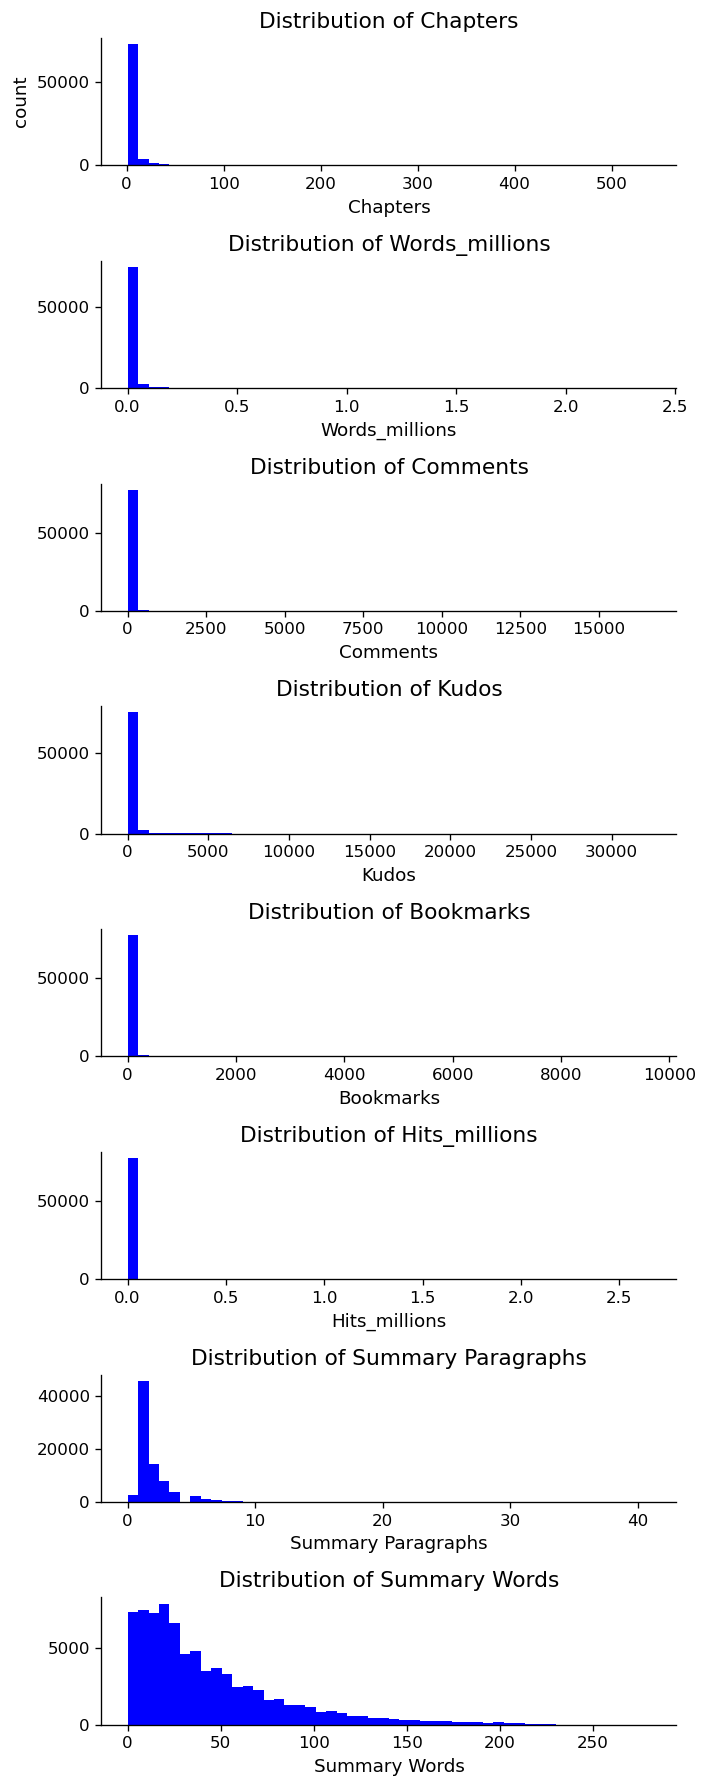

In [310]:
num_features = ['Chapters',
       'Words_millions', 'Comments', 'Kudos', 'Bookmarks',
       'Hits_millions', 'Summary Paragraphs','Summary Words']
n = len(num_features)
fig, axes =plt.subplots(n, 1,  figsize= (6,15))
# fig.subtitle("Distribution of the num features", fontsize=15, y=1.01)

for j, col in enumerate(num_features):
    
    axes[j].hist(features[col], bins=50, color="blue", lw=0.4)
    axes[j].set_xlabel(col)
    axes[j].set_ylabel("count" if j==0 else "")
    axes[j].set_title(f"Distribution of {col}")
    plt.tight_layout()
    

the distribution of num features is not normal however I am not going to use them directly I am going to use ratios and sample size is large

In [43]:
features['kudos/hits'] = (features["Kudos"] / features["Hits"]).replace([np.inf, -np.inf], 0)

In [44]:
features['comments/hits'] = (features["Comments"] / features["Hits"]).replace([np.inf, -np.inf], 0)

In [45]:
features['bookmarks/hits'] = (features["Bookmarks"] / features["Hits"]).replace([np.inf, -np.inf], 0)

In [63]:
features["Fandom Tags"] = features["Fandom Tags"].apply(ast.literal_eval)

In [ ]:
#[Claude] BEGIN  i have a column with a list of tags and a column in a different dataframe with how many times a tag is used we will call that size \
# how can i create a new column in df1 with the correct size depending on the list of tags

size_map =  dict(zip(fandom["name"], fandom["cached_count"]))
features["fandom_size"] = features["Fandom Tags"].apply(lambda tag_list: max((size_map.get(tag, 0) for tag in tag_list), default=0))

#END

fandom size here is based on the tag dataset cause this dataset is from the website with the true size of each fandom not just from the count of the tag in this sample 

a work can have multiple fandom tags I decided to take the max size for example if a work is in jjk_manga (size= 50) and jjk_anime (size = 100) the result size will be 100 cause the sum doesn't make sense as a the 50 work in the jjk_manga are probably within the 100 work in jjk_anime meaning there are 50 work that is tagged jjk_manga and jjk_anime while there are 50 work tagged only jjk_anime of course that is not always the case but within fandom spaces that is the assumption. 

In [66]:
features.head(5)

,Unnamed: 0,URL,Title,Authors,Rating Tags,Warning Tags,Category Tags,Fandom Tags,Relationship Tags,Character Tags,...,Hits,Summary Paragraphs,Summary Words,Summary Characters,kudos/hits,comments/hits,bookmarks/hits,Words_millions,Hits_millions,fandom_size
0,0,https://archiveofourown.org/works/33980032,Warm Hugs from Close Friends,"['AbsentReverie', 'NightTanzy']",[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' F/M'],"[Persona Series, Persona 3, Persona 4]","['Arisato Minako/Narukami Yu', 'Female Persona...","['Arisato Minako', 'Arisato Minato', 'Narukami...",...,671,4,179,1033,0.043219,0.004471,0.001490,0.002648,0.000671,7652
1,1,https://archiveofourown.org/works/33979747,Tornado Warning,['coughsyrup'],[' Explicit'],"[' Rape/Non-Con', 'Underage Sex']",[' M/M'],[Persona 4],['Adachi Tohru/Tatsumi Kanji'],"['Adachi Tohru', 'Tatsumi Kanji']",...,1508,1,8,50,0.054377,0.003316,0.003979,0.002786,0.001508,7337
2,2,https://archiveofourown.org/works/33469771,Baton Pass,['CatMcHall'],[' Teen And Up Audiences'],"[' Graphic Depictions Of Violence', 'Major Cha...",[' F/M'],[Persona 5],['Kurusu Akira/Niijima Makoto'],"['Kurusu Akira', 'Niijima Makoto', 'Takamaki A...",...,2950,5,116,659,0.023729,0.007458,0.006102,0.010789,0.002950,21922
3,3,https://archiveofourown.org/works/33967459,"All For You, Darling",['Squidapples'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' M/M'],[Persona 5],"['Akechi Goro/Persona 5 Protagonist', 'Akechi ...","['Amamiya Ren (Persona Series)', 'Akechi Goro'...",...,1555,1,27,152,0.040514,0.000643,0.005145,0.002669,0.001555,21922
4,4,https://archiveofourown.org/works/33976522,"i glance at you, i miss you a bit",['summerscouts'],[' General Audiences'],[' No Archive Warnings Apply'],[' M/M'],[Persona 5],"['Persona 5 Protagonist/Sakamoto Ryuji', 'Kuru...","['Sakamoto Ryuji', 'Amamiya Ren (Persona Serie...",...,579,2,27,148,0.086356,0.000000,0.001727,0.000730,0.000579,21922


we will drop works whose fandom size is less than 100 as we don't want works that are varial within a very small fandom to bias our model as normally if a fandom really small 20 works for example one work or two will definetly have more hits than the size of the fandom. 

In [67]:
features = features[features["fandom_size"] > 100]

In [68]:
features['hits/size'] = features["Hits"] / features["fandom_size"]

In [71]:
features.columns

Index(['Unnamed: 0', 'URL', 'Title', 'Authors', 'Rating Tags', 'Warning Tags',
       'Category Tags', 'Fandom Tags', 'Relationship Tags', 'Character Tags',
       'Freeform Tags', 'Language Tags', 'Published', 'Updated',
       'Pos_in_series', 'Completion', 'Chapters', 'Intended_chapters', 'Words',
       'Comments', 'Kudos', 'Bookmarks', 'Hits', 'Summary Paragraphs',
       'Summary Words', 'Summary Characters', 'kudos/hits', 'comments/hits',
       'bookmarks/hits', 'Words_millions', 'Hits_millions', 'fandom_size',
       'hits/size'],
      dtype='object')

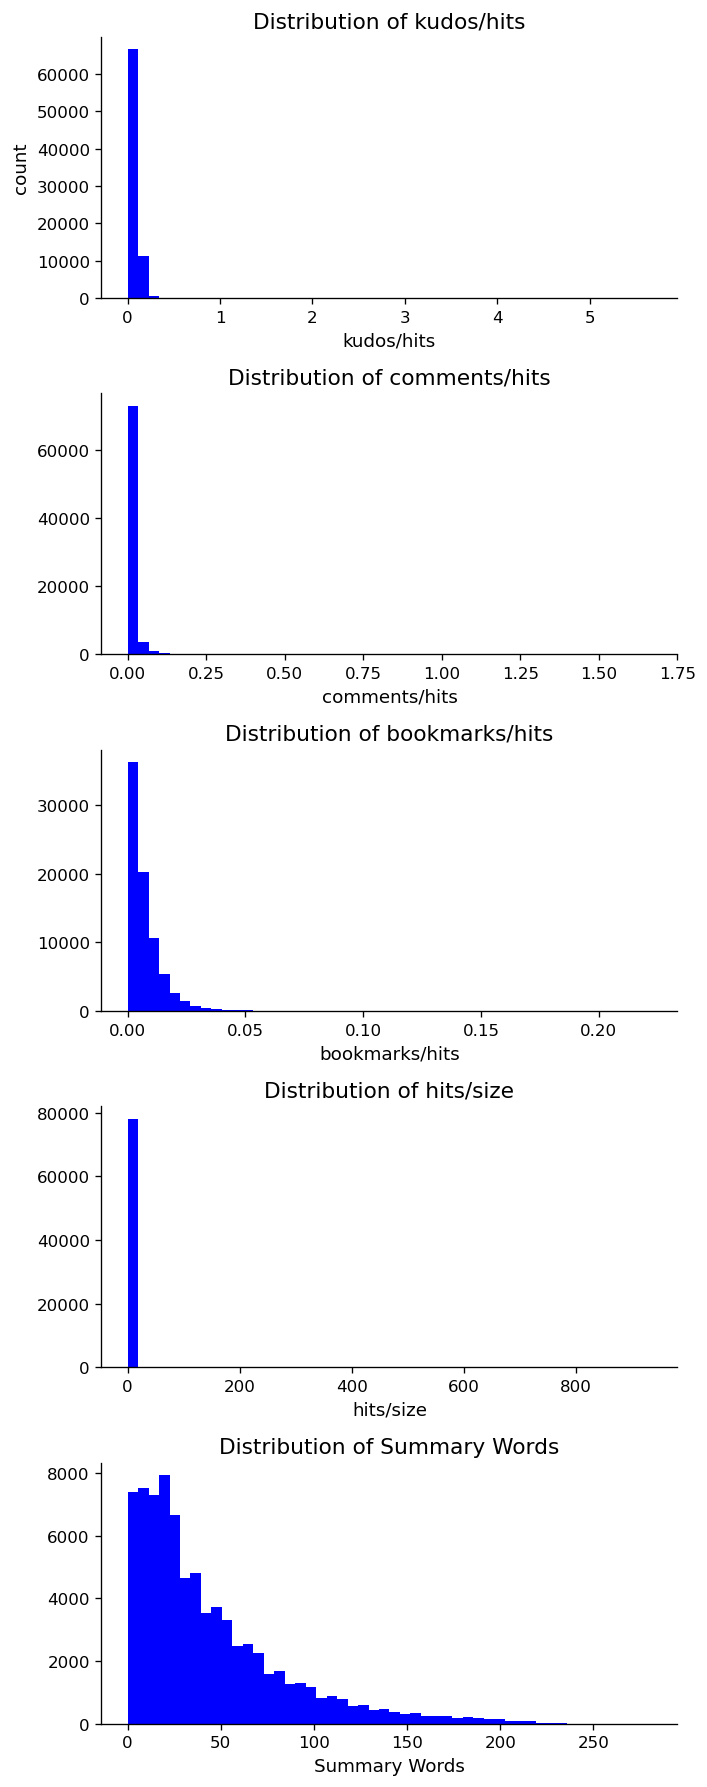

In [309]:
num_features = [ 'kudos/hits', 'comments/hits',
       'bookmarks/hits',
       'hits/size', 'Summary Words']
n = len(num_features)
fig, axes =plt.subplots(n, 1,  figsize= (6,15))
# fig.subtitle("Distribution of the num features", fontsize=15, y=1.01)

for j, col in enumerate(num_features):
    
    axes[j].hist(features[col], bins=50, color="blue", lw=0.4)
    axes[j].set_xlabel(col)
    axes[j].set_ylabel("count" if j==0 else "")
    axes[j].set_title(f"Distribution of {col}")
    plt.tight_layout()
    

In [ ]:
# for i, col in enumerate(num_features):
#     features[f"log_{col}"] = np.log1p(features[col])

In [307]:
# fig, axes =plt.subplots(n, 1,  figsize= (6,15))
# for j, col in enumerate(num_features):
    
#     axes[j].hist(features[f"log_{col}"], bins=50, color="blue", lw=0.4)
#     axes[j].set_xlabel(f"log_{col}")
#     axes[j].set_ylabel("count" if j==0 else "")
#     axes[j].set_title(f"log_{col}")
#     plt.tight_layout()

word count per work will be converted to categories based on words and chapters count this is because this is how people precive fanfictions and we are trying to predict what makes a fic popular or atleast attractive for people to check it 

a fan work with 0 words means its either a podfic or fanart we will drop those

In [82]:
features = features[features["Words"] > 0]

In [85]:
features.shape

(78544, 41)

In [ ]:
fic_size_map = {
    
    'short_multiple': (0,85000),
    'medium': (85000, 250000),
    'long': (250000, 2500000)
}

def map_size(chapter, word):
    for category, (low_w, high_w) in fic_size_map.items():
        if chapter == 1:
            return "oneshot"
        elif low_w <  word <= high_w:
            return category
    return "other"

        

# [Claude] BEGIN can I apply this to two columns in my dataframe and I attached the size function

features["fic_size"] = features.apply(lambda row: map_size(row['Chapters'], row['Words']), axis=1)

#END

Text(0, 0.5, 'Count')

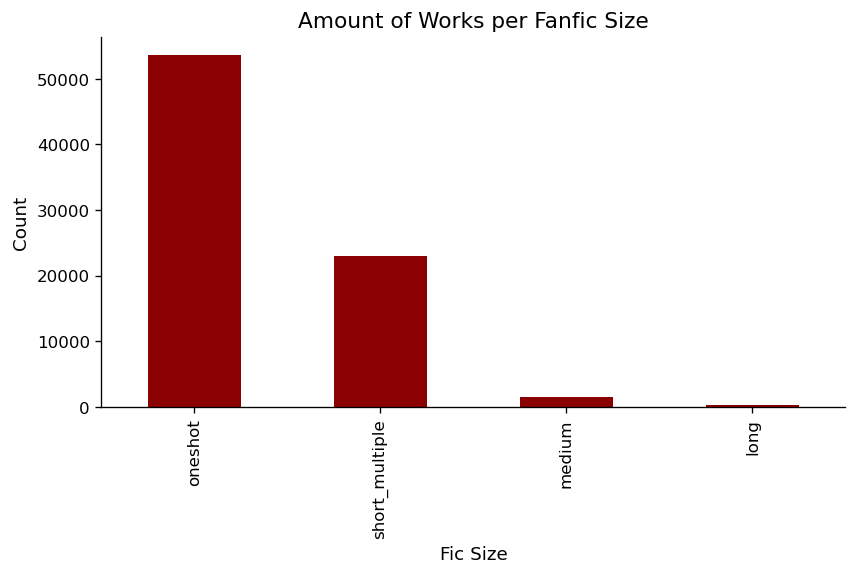

In [311]:
fig, ax = plt.subplots(1, figsize=(8, 4))


features['fic_size'].value_counts().sort_values(ascending= False).plot(kind='bar', color='darkred', ax = ax)

ax.set_title("Amount of Works per Fanfic Size")
ax.set_xlabel("Fic Size")
ax.set_ylabel("Count")

## TEXT DATA

In [158]:
records = []
with open('ao3_1-100000.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

In [159]:
records = []
with open('ao3_100001-200000.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        records.append(json.loads(line))

df2 = pd.DataFrame(records)

In [160]:
df = pd.concat([df, df2], ignore_index=True)

source: https://www.pythontutorials.net/blog/reading-rather-large-json-files/ 

In [161]:
df.head(5)

,id,title,metadata,text
0,16,Proximity,{'Archive Warning': 'Creator Chose Not To Use ...,Cook liked touching people. Really liked it. H...
1,31,Pixiestix,"{'Additional Tags': 'Kissing, commentfic, Band...","Sometimes, Frank liked to give Gerard pixie st..."
2,175,Ghost in the Machine,"{'Additional Tags': 'Artificial Intelligence, ...","It is 05:35 Greenwich Mean Time, and I am anal..."
3,150,Justin is the Verizon,"{'Additional Tags': 'Crack Fic, Popslash - Fre...","""Hey, can you hear me now?"" Justin looked arou..."
4,22,like a,"{'Additional Tags': 'OT3, Songfic, Humor, Fluf...",…to make it up I do whatever it takeI love you...


In [162]:
meta_df = pd.json_normalize(df['metadata'])
df_text = pd.concat([df.drop(columns=['metadata']), meta_df], axis=1)

In [163]:
df_text.head(10)

,id,title,text,Archive Warning,Category,Characters,Fandom,Language,Rating,Relationship,...,published,words,Additional Tags,Fandoms,Character,Collections,Series,Relationships,Archive Warnings,Categories
0,16,Proximity,Cook liked touching people. Really liked it. H...,Creator Chose Not To Use Archive Warnings,M/M,"David Archuleta, David Cook",American Idol RPF (Season 7),English,Teen And Up Audiences,Cook/Archuleta,...,2008-09-13,"2,482",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,31,Pixiestix,"Sometimes, Frank liked to give Gerard pixie st...",Creator Chose Not To Use Archive Warnings,Other,"Mikey Way, Gerard Way, Frank Iero",NaN,English,Not Rated,Mikey Way/Gerard Way,...,2008-05-26,64,"Kissing, commentfic, Bandslash","My Chemical Romance, Six Degrees of Pete Wentz...",NaN,NaN,NaN,NaN,NaN,NaN
2,175,Ghost in the Machine,"It is 05:35 Greenwich Mean Time, and I am anal...",No Archive Warnings Apply,Gen,NaN,Quantum Leap,English,General Audiences,NaN,...,2007-09-21,"1,279","Artificial Intelligence, Mysticism, POV First ...",NaN,Ziggy (Quantum Leap),Robots and artificial lifeforms,NaN,NaN,NaN,NaN
3,150,Justin is the Verizon,"""Hey, can you hear me now?"" Justin looked arou...",Creator Chose Not To Use Archive Warnings,Other,"Justin Timberlake, Nelly",NSYNC,English,Not Rated,NaN,...,2002-07-16,250,"Crack Fic, Popslash - Freeform, Character of C...",NaN,NaN,NaN,Scenes from a Hat,NaN,NaN,NaN
4,22,like a,…to make it up I do whatever it takeI love you...,No Archive Warnings Apply,M/M,"Rodney McKay, John Sheppard, Ronon Dex",Stargate Atlantis,English,Not Rated,John Sheppard/Rodney McKay/Ronon Dex,...,2006-01-06,"1,755","OT3, Songfic, Humor, Fluff, Character of Color...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,176,Allowances,"Ray whispers it to Stella's collarbone, to her...",No Archive Warnings Apply,F/M,"Ray Kowalski, Stella Kowalski (due South)",due South,English,Teen And Up Audiences,Ray Kowalski/Stella Kowalski,...,2003-06-30,180,"Flash Fic, Ficlet",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,40,Knight Moves,"The spell slammed Sam into the Impala, his hea...",Creator Chose Not To Use Archive Warnings,Other,"Sam Winchester, Dean Winchester",Supernatural,English,Not Rated,NaN,...,2008-09-15,"4,043",First Time,NaN,NaN,NaN,Moves,NaN,NaN,NaN
7,227,If youre as bored as I,You remember that time we went skiing in the A...,No Archive Warnings Apply,Other,"Sandy Justine, zvi",Slasher RPF,English,Not Rated,NaN,...,2005-12-01,123,"RPF, Humor, Meme, commentfic, Character of Color",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,43,Mindless Fun,"one, two, threeJohn looked at D'Argo's outstre...",Creator Chose Not To Use Archive Warnings,M/M,"John Crichton, Ka D'Argo",Farscape,English,Not Rated,John/D'Argo,...,2001-05-07,461,NaN,NaN,NaN,Interspecies,NaN,NaN,NaN,NaN
9,183,To Drive the Cold Winter,"Winter, and the Parisian skies are bitter and ...",No Archive Warnings Apply,Gen,"Methos, Duncan MacLeod",Highlander: The Series,English,General Audiences,NaN,...,2007-12-01,920,"Holiday, Christmas, Winter, POV Second Person",NaN,NaN,Second Person POV,NaN,NaN,NaN,NaN


In [164]:
print(f"Shape: {df_text.shape}")
print(f"\nColumn types:\n{df_text.dtypes}")

Shape: (165461, 23)

Column types:
id                  object
title               object
text                object
Archive Warning     object
Category            object
Characters          object
Fandom              object
Language            object
Rating              object
Relationship        object
author              object
chapters            object
completed           object
published           object
words               object
Additional Tags     object
Fandoms             object
Character           object
Collections         object
Series              object
Relationships       object
Archive Warnings    object
Categories          object
dtype: object


In [165]:
df_text.isnull().sum()

id                       0
title                    0
text                     0
Archive Warning       4447
Category             15860
Characters           38299
Fandom               22491
Language               356
Rating                 356
Relationship         65290
author                 356
chapters               356
completed              356
published              356
words                  356
Additional Tags      48520
Fandoms             143328
Character           150907
Collections         136841
Series              137677
Relationships       147757
Archive Warnings    161370
Categories          155797
dtype: int64

### DATA CLEANING

In [174]:
df = df_text.copy()

there are 356 rows that are missing that we can easily just drop given that the dataset is large in size

In [175]:
df = df.dropna(subset=["words"]) 

In [176]:
df.isnull().sum()

id                       0
title                    0
text                     0
Archive Warning       4091
Category             15504
Characters           37943
Fandom               22135
Language                 0
Rating                   0
Relationship         64934
author                   0
chapters                 0
completed                0
published                0
words                    0
Additional Tags      48164
Fandoms             142972
Character           150551
Collections         136485
Series              137321
Relationships       147401
Archive Warnings    161014
Categories          155441
dtype: int64

In [177]:
df.columns

Index(['id', 'title', 'text', 'Archive Warning', 'Category', 'Characters',
       'Fandom', 'Language', 'Rating', 'Relationship', 'author', 'chapters',
       'completed', 'published', 'words', 'Additional Tags', 'Fandoms',
       'Character', 'Collections', 'Series', 'Relationships',
       'Archive Warnings', 'Categories'],
      dtype='object')

i will check the percentage of missing values in each column to see if i will drop the column, drop rows or find a solution to replace the nan values

In [178]:
nan_columns = ['Archive Warning', 'Category', 'Characters',
       'Fandom',  'Relationship',  'Additional Tags', 'Fandoms',
       'Character', 'Collections', 'Series', 'Relationships',
       'Archive Warnings', 'Categories']
for i, col in enumerate(nan_columns):
       print(f"Percentage of missing values in {col}  column {df[col].isna().mean() * 100 :.2f} %")

Percentage of missing values in Archive Warning  column 2.48 %
Percentage of missing values in Category  column 9.39 %
Percentage of missing values in Characters  column 22.98 %
Percentage of missing values in Fandom  column 13.41 %
Percentage of missing values in Relationship  column 39.33 %
Percentage of missing values in Additional Tags  column 29.17 %
Percentage of missing values in Fandoms  column 86.59 %
Percentage of missing values in Character  column 91.19 %
Percentage of missing values in Collections  column 82.67 %
Percentage of missing values in Series  column 83.17 %
Percentage of missing values in Relationships  column 89.28 %
Percentage of missing values in Archive Warnings  column 97.52 %
Percentage of missing values in Categories  column 94.15 %


columns with missing values above 80% will be dropped, for relationship, Characters, and Additional Tags columns nan means the author choose not to include them so i won't drop their missing values I will change it to N/A, I will drop missing values in fandom, Archive Warning and category as it is a small percentage

In [179]:
df = df.drop(columns=['Fandoms', 'Character', 'Collections', 'Series', 'Relationships', 'Archive Warnings', 'Categories'])

In [180]:
df = df.dropna(subset=['Category', 'Fandom', 'Archive Warning'])

In [189]:
df['Characters'] = df['Characters'].replace(np.nan, 'N/A')
df['Relationship'] = df['Relationship'].replace(np.nan, 'N/A')
df['Additional Tags'] = df['Additional Tags'].replace(np.nan, 'N/A')

I will convert chapter count and word count to int 

In [182]:
df['chapter_num'] = df['chapters'].str.split('/').str[0].astype(int)
df['word_count'] = df['words'].str.replace(',', '').astype(int)

In [190]:
df.head(5)

,id,title,text,Archive Warning,Category,Characters,Fandom,Language,Rating,Relationship,author,chapters,completed,published,words,Additional Tags,chapter_num,word_count,fic_size
0,16,Proximity,Cook liked touching people. Really liked it. H...,Creator Chose Not To Use Archive Warnings,M/M,"David Archuleta, David Cook",American Idol RPF (Season 7),English,Teen And Up Audiences,Cook/Archuleta,by astolat,1/1,,2008-09-13,"2,482",N/A,1,2482,oneshot
2,175,Ghost in the Machine,"It is 05:35 Greenwich Mean Time, and I am anal...",No Archive Warnings Apply,Gen,N/A,Quantum Leap,English,General Audiences,N/A,by juniperphoenix,1/1,,2007-09-21,"1,279","Artificial Intelligence, Mysticism, POV First ...",1,1279,oneshot
3,150,Justin is the Verizon,"""Hey, can you hear me now?"" Justin looked arou...",Creator Chose Not To Use Archive Warnings,Other,"Justin Timberlake, Nelly",NSYNC,English,Not Rated,N/A,by WitchQueen (zvi),1/1,,2002-07-16,250,"Crack Fic, Popslash - Freeform, Character of C...",1,250,oneshot
4,22,like a,…to make it up I do whatever it takeI love you...,No Archive Warnings Apply,M/M,"Rodney McKay, John Sheppard, Ronon Dex",Stargate Atlantis,English,Not Rated,John Sheppard/Rodney McKay/Ronon Dex,by zvi,1/1,,2006-01-06,"1,755","OT3, Songfic, Humor, Fluff, Character of Color...",1,1755,oneshot
5,176,Allowances,"Ray whispers it to Stella's collarbone, to her...",No Archive Warnings Apply,F/M,"Ray Kowalski, Stella Kowalski (due South)",due South,English,Teen And Up Audiences,Ray Kowalski/Stella Kowalski,by ignaz,1/1,,2003-06-30,180,"Flash Fic, Ficlet",1,180,oneshot


In [184]:
print(f"Shape: {df_text.shape}")

Shape: (165461, 23)


Text(0, 0.5, 'Count')

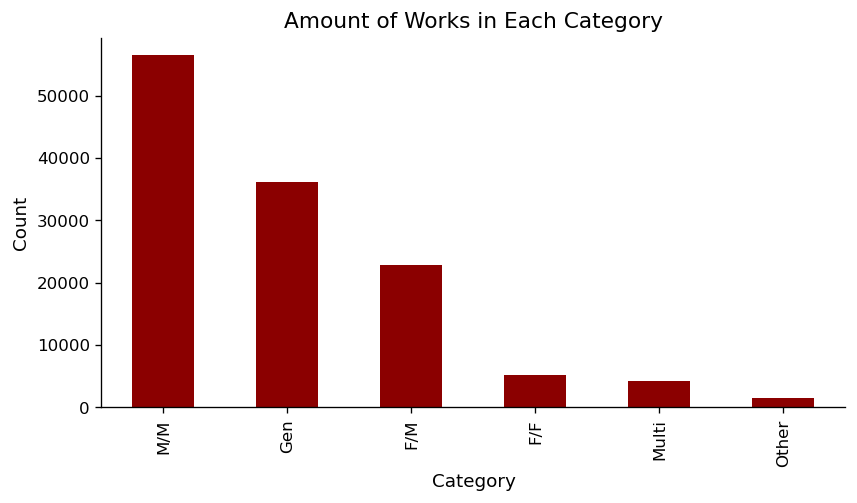

In [192]:
fig, ax = plt.subplots(1, figsize=(8, 4))


df['Category'].value_counts().sort_values(ascending= False).plot(kind='bar', color='darkred', ax = ax)

ax.set_title("Amount of Works in Each Category")
ax.set_xlabel("Category")
ax.set_ylabel("Count")

I am excluding fan work that is art or podfic in this dataset as well 

In [186]:
df = df[df["word_count"] > 0]

In [ ]:
fic_size_map = {
    'short_multiple': (0,85000),
    'medium': (85000, 250000),
    'long': (250000, 2500000)
}

def map_size(chapter, word):
    for category, (low_w, high_w) in fic_size_map.items():
        if chapter == 1:
            return "oneshot"
        elif low_w <  word <= high_w:
            return category
    return "other"

        

# [Claude] BEGIN can I apply this to two columns in my dataframe and I attached the size function

df["fic_size"] = df.apply(lambda row: map_size(row['chapter_num'], row['word_count']), axis=1)

#END

Text(0, 0.5, 'Count')

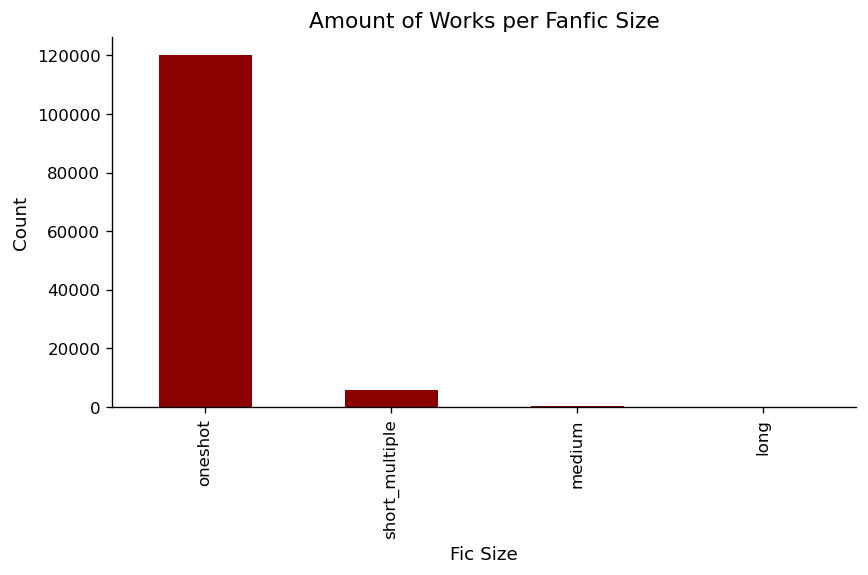

In [312]:
fig, ax = plt.subplots(1, figsize=(8, 4))

df['fic_size'].value_counts().sort_values(ascending= False).plot(kind='bar', color='darkred', ax = ax)

ax.set_title("Amount of Works per Fanfic Size")
ax.set_xlabel("Fic Size")
ax.set_ylabel("Count")

I will combine additional tags, charachters and relationship into one column

In [326]:
df.columns

Index(['id', 'title', 'text', 'Archive Warning', 'Category', 'Characters',
       'Fandom', 'Language', 'Rating', 'Relationship', 'author', 'chapters',
       'completed', 'published', 'words', 'Additional Tags', 'chapter_num',
       'word_count', 'fic_size', 'tags_list'],
      dtype='object')

In [327]:
df['combined_tags'] = df[['Characters', 'Relationship', "Additional Tags"]].agg(','.join, axis=1).str.strip()

i will convert combined_tags into a list

In [328]:
df['tags_list'] = df['combined_tags'].str.split(',')
df['tags_list'] = df['tags_list'].apply(lambda tags: [t.strip() for t in tags])
df['tags_list'].iloc[2]

['Justin Timberlake',
 'Nelly',
 'N/A',
 'Crack Fic',
 'Popslash - Freeform',
 'Character of Color']

Text(0, 0.5, 'Count')

c:\Users\kareman\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\kareman\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\kareman\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\kareman\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\kareman\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 35805 (\N{CJK UNIFIED IDEOGRAPH-8BDD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\kareman\anaconda3\Lib\site-packages\IPython\core\ev

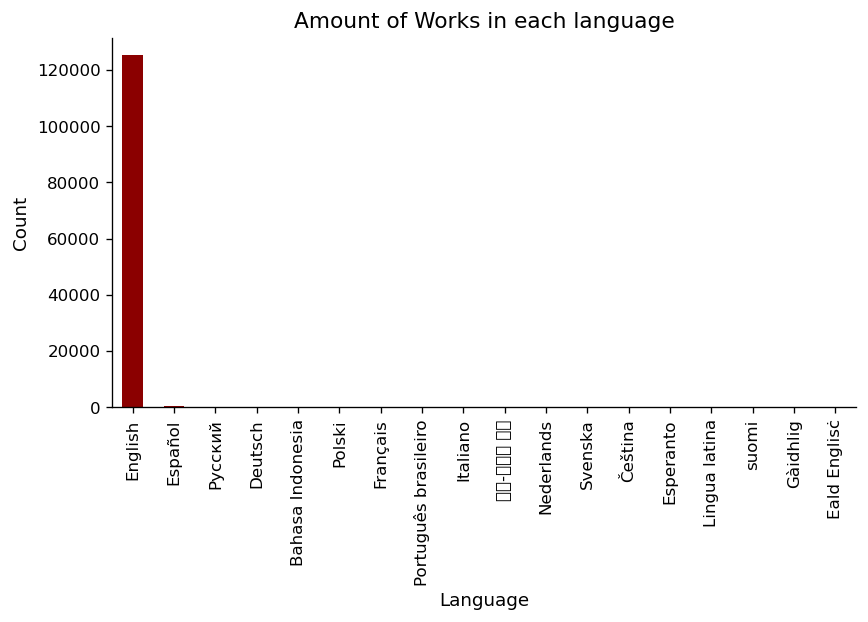

In [315]:
fig, ax = plt.subplots(1, figsize=(8, 4))

df['Language'].value_counts().sort_values(ascending= False).plot(kind='bar', color='darkred', ax = ax)

ax.set_title("Amount of Works in each language")
ax.set_xlabel("Language")
ax.set_ylabel("Count")

as we can see most works are in english so I will keep works that are only in english for easier text feature extraction

In [316]:
df = df[df["Language"] == "English"]

In [330]:
print(f"Shape: {df.shape}")

Shape: (125271, 21)


## Features

In [ ]:
# # BEGIN [google Geminie]  TF-IDF Feature Extraction in pandas 

# # stop_words='english' removes common words like 'is', 'a', 'the'
# vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')

# # Fit and transform the text column
# tfidf_matrix = vectorizer.fit_transform(df['Additional Tags'])

# # Convert TF-IDF matrix to DataFrame for better readability
# tfidf_df = pd.DataFrame(
#     tfidf_matrix.toarray(),
#     columns=vectorizer.get_feature_names_out(),
#     index=df['id']
# )

# # END 

##### Embedding

embedding for additional tags because tags with similar meaning but different word choices will be closer in vector space

In [329]:
# BEGIN [Claude] Word Embeddings with large pandas dataset 
model = SentenceTransformer('all-MiniLM-L6-v2')

unique_tags = df['combined_tags'].explode().unique() 
tag_embeddings = model.encode(unique_tags.tolist(), convert_to_numpy=True)

tag_to_embedding = dict(zip(unique_tags, tag_embeddings))
    

#END

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\kareman\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kareman\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]